In [41]:
import requests
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Scraping Dataset

In [33]:
API_KEY = "d75b0b7c1ce04bd882c80e8e97d17fc4"

data_game = []

for page in range(1, 41):
    url = f"https://api.rawg.io/api/games?key={API_KEY}&page={page}&page_size=40"
    
    response = requests.get(url)
    
    if response.status_code == 200:
        data = response.json()
        
        for game in data["results"]:
            data_game.append({
                "id": game["id"],
                "name": game["name"],
                "released": game.get("released"),
                "rating": game.get("rating"),
                "ratings_count": game.get("ratings_count"),
                "metacritic": game.get("metacritic"),
                "playtime": game.get("playtime"),
                "genres": ", ".join(
                    genre["name"] for genre in game.get("genres", [])
                )
            })
            
    else:
        print("Error pada halaman", page)
        print("Status code:", response.status_code)
        break
    
    time.sleep(0.3)

df = pd.DataFrame(data_game)

df.to_csv("rawg_games_raw.csv", index=False)
print(df.shape)

(1600, 8)


## 2. Import dan Pemahaman Dataset

In [34]:
df = pd.read_csv('rawg_games_raw.csv')
df.head()

,id,name,released,rating,ratings_count,metacritic,playtime,genres
0,3498,Grand Theft Auto V,2013-09-17,4.47,7441,92.0,74,Action
1,3328,The Witcher 3: Wild Hunt,2015-05-18,4.64,7276,92.0,43,"Action, RPG"
2,4200,Portal 2,2011-04-18,4.57,6140,95.0,11,"Shooter, Puzzle"
3,4291,Counter-Strike: Global Offensive,2012-08-21,3.57,3645,81.0,64,Shooter
4,13536,Portal,2007-10-09,4.49,5055,90.0,4,"Action, Puzzle"


In [10]:
print(df.info())
print(df.shape)
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             1600 non-null   int64  
 1   name           1600 non-null   object 
 2   released       1597 non-null   object 
 3   rating         1600 non-null   float64
 4   ratings_count  1600 non-null   int64  
 5   metacritic     1311 non-null   float64
 6   playtime       1600 non-null   int64  
 7   genres         1597 non-null   object 
dtypes: float64(2), int64(3), object(3)
memory usage: 100.1+ KB
None
(1600, 8)
id                 int64
name              object
released          object
rating           float64
ratings_count      int64
metacritic       float64
playtime           int64
genres            object
dtype: object


In [36]:
tipe_atribut = pd.DataFrame({
    "Atribut": [
        "id",
        "name",
        "released",
        "rating",
        "ratings_count",
        "metacritic",
        "playtime",
        "genres"
    ],
    "Jenis Atribut": [
        "Numerik diskrit",
        "Nominal",
        "Temporal",
        "Numerik kontinu",
        "Numerik diskrit",
        "Numerik diskrit",
        "Numerik diskrit",
        "Nominal"
    ],
    "Penjelasan": [
        "ID unik untuk setiap game.",
        "Nama atau judul game.",
        "Tanggal perilisan game.",
        "Nilai rata-rata rating game.",
        "Jumlah pengguna yang memberikan rating.",
        "Skor Metacritic yang diperoleh game.",
        "Perkiraan waktu bermain dalam jam.",
        "Genre yang dimiliki oleh game."
    ]
})

tipe_atribut

,Atribut,Jenis Atribut,Penjelasan
0,id,Numerik diskrit,ID unik untuk setiap game.
1,name,Nominal,Nama atau judul game.
2,released,Temporal,Tanggal perilisan game.
3,rating,Numerik kontinu,Nilai rata-rata rating game.
4,ratings_count,Numerik diskrit,Jumlah pengguna yang memberikan rating.
5,metacritic,Numerik diskrit,Skor Metacritic yang diperoleh game.
6,playtime,Numerik diskrit,Perkiraan waktu bermain dalam jam.
7,genres,Nominal,Genre yang dimiliki oleh game.


## 3. Analisis Statistik dan Kualitas Data


In [37]:
numerik_cols = ['rating', 'ratings_count', 'metacritic', 'playtime']

for col in numerik_cols:
    print(f"--- {col} ---")
    print(f"Mean   : {df[col].mean():.2f}")
    print(f"Median : {df[col].median():.2f}")
    print(f"Modus  : {df[col].mode()[0]}")
    print(f"Std    : {df[col].std():.2f}")
    print(f"Min    : {df[col].min()}")
    print(f"Max    : {df[col].max()}")
    print()

--- rating ---
Mean   : 3.62
Median : 3.73
Modus  : 4.37
Std    : 0.59
Min    : 1.68
Max    : 4.75

--- ratings_count ---
Mean   : 689.47
Median : 430.00
Modus  : 179
Std    : 756.58
Min    : 30
Max    : 7441

--- metacritic ---
Mean   : 78.97
Median : 80.00
Modus  : 80.0
Std    : 8.46
Min    : 40.0
Max    : 99.0

--- playtime ---
Mean   : 5.61
Median : 4.00
Modus  : 3
Std    : 11.08
Min    : 0
Max    : 329



In [38]:
genre_split = df["genres"].dropna().str.split(", ").explode()

print("Distribusi Genre:")
print(genre_split.value_counts())

Distribusi Genre:
genres
Action                   1083
Adventure                 607
Indie                     532
RPG                       394
Shooter                   314
Strategy                  265
Simulation                180
Casual                    131
Platformer                118
Puzzle                    114
Arcade                    101
Massively Multiplayer      68
Racing                     67
Sports                     47
Family                     33
Fighting                   28
Card                       10
Educational                 9
Board Games                 7
Name: count, dtype: int64


In [39]:
missing = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Jumlah Missing": missing,
    "Persentase (%)": (missing / len(df) * 100).round(2)
})

missing_summary

,Jumlah Missing,Persentase (%)
id,0,0.00
name,0,0.00
released,3,0.19
rating,0,0.00
ratings_count,0,0.00
metacritic,289,18.06
playtime,0,0.00
genres,3,0.19


In [40]:
for col in numerik_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[col] < batas_bawah) | 
        (df[col] > batas_atas)
    ]
    
    print(f"--- {col} ---")
    print("Batas bawah :", round(batas_bawah, 2))
    print("Batas atas  :", round(batas_atas, 2))
    print("Jumlah outlier:", len(outliers))
    print()

--- rating ---
Batas bawah : 2.09
Batas atas  : 5.26
Jumlah outlier: 26

--- ratings_count ---
Batas bawah : -680.38
Batas atas  : 1744.62
Jumlah outlier: 134

--- metacritic ---
Batas bawah : 57.5
Batas atas  : 101.5
Jumlah outlier: 18

--- playtime ---
Batas bawah : -4.0
Batas atas  : 12.0
Jumlah outlier: 131



## 4. Visualisasi Data

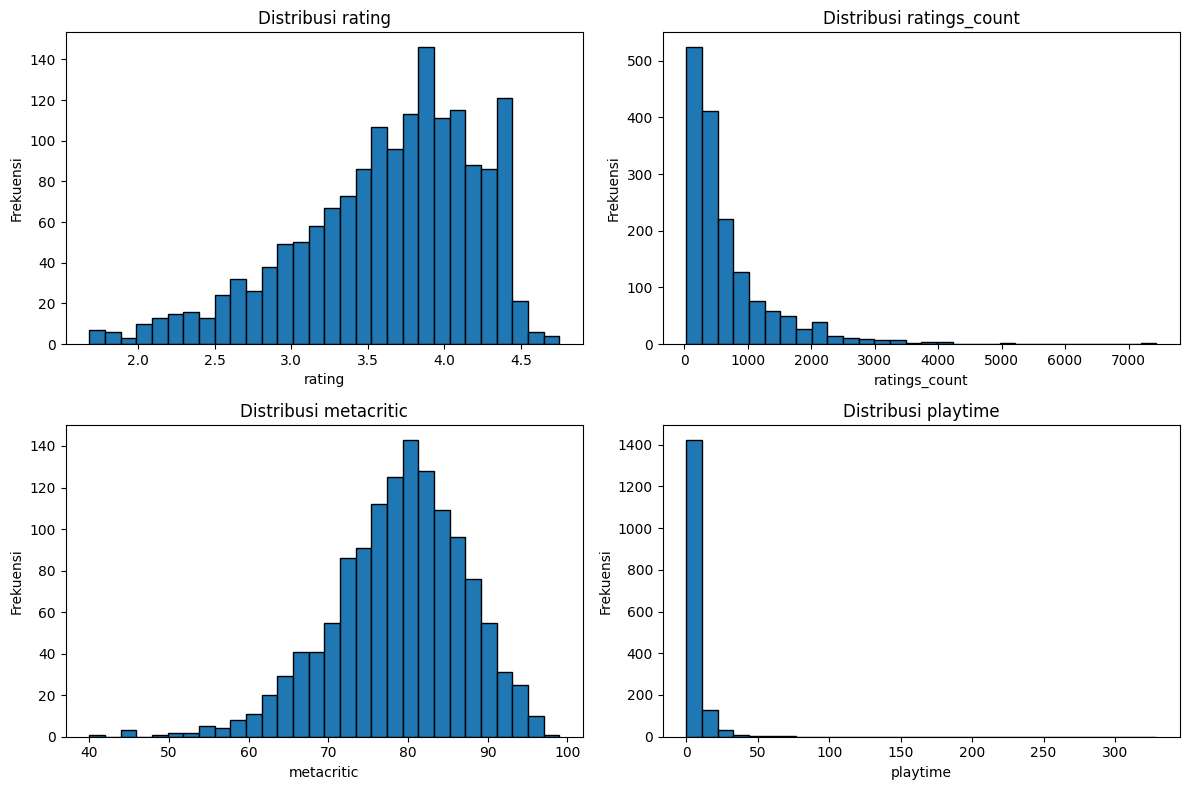

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numerik_cols):
    axes[i].hist(df[col].dropna(), bins=30, edgecolor="black")
    axes[i].set_title(f"Distribusi {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frekuensi")

plt.tight_layout()
plt.show()

Distribusi rating menunjukkan bahwa sebagian besar game memiliki rating pada rentang tertentu, sedangkan game dengan rating sangat rendah maupun sangat tinggi jumlahnya relatif lebih sedikit.

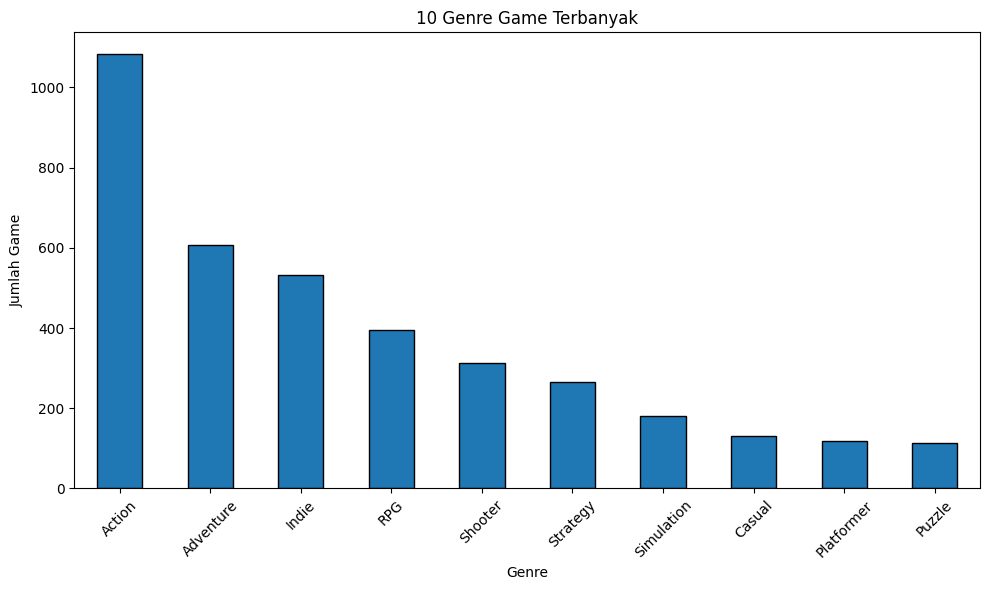

In [43]:
genre_split = df["genres"].dropna().str.split(", ").explode()
top_genres = genre_split.value_counts().head(10)

plt.figure(figsize=(10, 6))

top_genres.plot(kind="bar", edgecolor="black")

plt.title("10 Genre Game Terbanyak")
plt.xlabel("Genre")
plt.ylabel("Jumlah Game")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Genre Action merupakan genre yang paling banyak ditemukan dalam dataset, sedangkan genre Puzzle memiliki jumlah game yang lebih rendah.

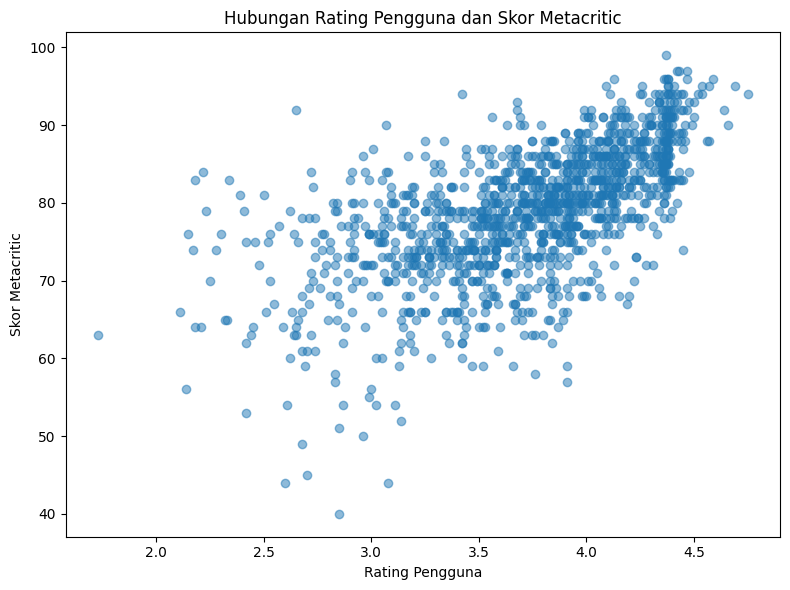

In [44]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["rating"],
    df["metacritic"],
    alpha=0.5
)

plt.title("Hubungan Rating Pengguna dan Skor Metacritic")
plt.xlabel("Rating Pengguna")
plt.ylabel("Skor Metacritic")

plt.tight_layout()
plt.show()

Scatter plot menunjukkan adanya kecenderungan hubungan positif antara rating pengguna dan skor Metacritic, meskipun terdapat beberapa data yang menunjukkan penyimpangan dari pola tersebut.


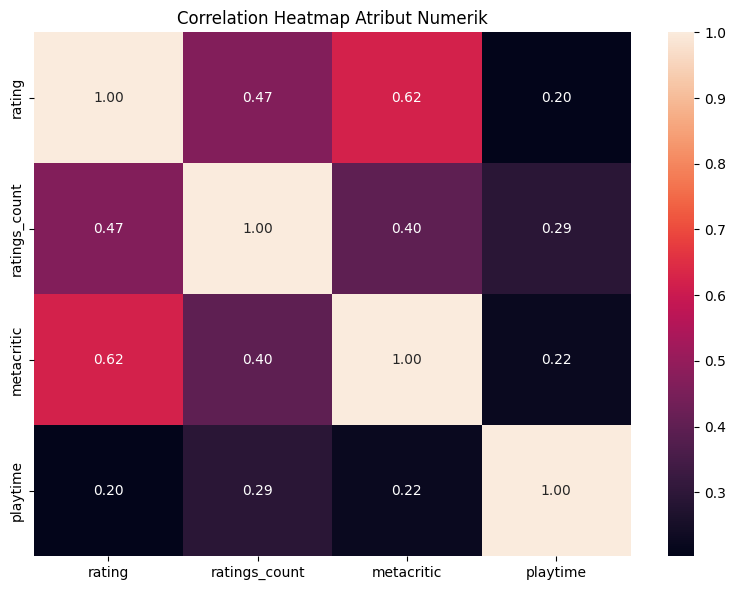

In [45]:
corr_matrix = df[numerik_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap Atribut Numerik")

plt.tight_layout()
plt.show()

Korelasi antara rating dan metacritic menunjukkan hubungan positif dengan tingkat korelasi tertentu. Sementara itu, beberapa atribut lainnya memiliki korelasi yang relatif lemah.

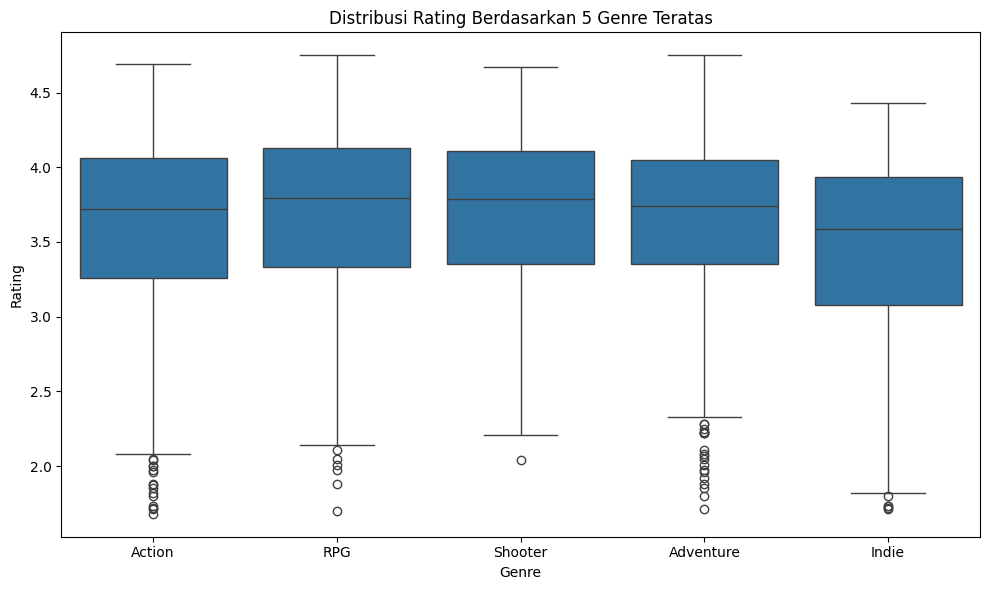

In [46]:
top5_genres = genre_split.value_counts().head(5).index

df_genre = df.copy()

df_genre["genres"] = df_genre["genres"].str.split(", ")
df_genre = df_genre.explode("genres")

df_genre = df_genre[
    df_genre["genres"].isin(top5_genres)
]

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_genre,
    x="genres",
    y="rating"
)

plt.title("Distribusi Rating Berdasarkan 5 Genre Teratas")
plt.xlabel("Genre")
plt.ylabel("Rating")

plt.tight_layout()
plt.show()